# Multi-Layer Perceptron From Scratch (Intuition + Full Pipeline)

This notebook builds an MLP manually (with NumPy math), while using sklearn only for:
- dataset loading
- preprocessing utilities (imputation/encoding/scaling)
- data splitting and metrics

What this notebook does:
1. Load dataset from sklearn
2. Let you choose target + feature columns
3. Handle nulls and duplicates with a smart size-based rule
4. Convert non-numeric columns to numeric with robust encoders
5. Auto-design MLP architecture from data
6. Train MLP manually with forward + backward pass
7. Evaluate and visualize results cleanly

In [3]:
# 1) Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2) Configuration (edit these values only)

You can change these values and re-run the notebook for a different dataset or feature selection.

In [4]:
# 3) User-editable config

# Built-in choices: 'iris', 'wine', 'breast_cancer', 'digits', 'openml_titanic'
dataset_name = 'iris'

# If None, notebook auto-detects target column
target_column = None

# If None, all feature columns are used; otherwise list explicit column names
selected_feature_columns = None

# Smart null policy threshold
row_threshold_for_drop = 1000

# Train config
test_size = 0.2
random_state = 42
learning_rate = 0.01
epochs = 250
batch_size = 32

# Architecture override (set None to auto)
hidden_layers_override = None

print('Configuration loaded.')

Configuration loaded.


In [5]:
# 4) Load sklearn dataset dynamically into DataFrame

if dataset_name == 'iris':
    ds = datasets.load_iris(as_frame=True)
    df = ds.frame.copy()
    dataset_title = 'Iris'
elif dataset_name == 'wine':
    ds = datasets.load_wine(as_frame=True)
    df = ds.frame.copy()
    dataset_title = 'Wine'
elif dataset_name == 'breast_cancer':
    ds = datasets.load_breast_cancer(as_frame=True)
    df = ds.frame.copy()
    dataset_title = 'Breast Cancer'
elif dataset_name == 'digits':
    ds = datasets.load_digits(as_frame=True)
    df = ds.frame.copy()
    dataset_title = 'Digits'
elif dataset_name == 'openml_titanic':
    ds = fetch_openml(name='titanic', version=1, as_frame=True)
    df = ds.frame.copy()
    if 'survived' in df.columns and 'target' not in df.columns:
        df['target'] = df['survived']
    dataset_title = 'OpenML Titanic'
else:
    raise ValueError('Unsupported dataset_name. Choose from iris, wine, breast_cancer, digits, openml_titanic.')

print(f'Dataset selected: {dataset_title}')
print('Shape:', df.shape)
display(df.head())

Dataset selected: Iris
Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
# 5) Smart data quality step: nulls + duplicates

null_count_before = int(df.isna().sum().sum())
duplicate_count_before = int(df.duplicated().sum())
rows_before = len(df)

print('Rows before cleaning:', rows_before)
print('Null values before cleaning:', null_count_before)
print('Duplicate rows before cleaning:', duplicate_count_before)

if rows_before > row_threshold_for_drop:
    # Large dataset: drop null rows, then drop duplicates
    df = df.dropna().drop_duplicates().reset_index(drop=True)
    cleaning_strategy = 'Dropped null rows + dropped duplicates (large dataset strategy)'
else:
    # Small dataset: impute smartly, then drop duplicates
    for col in df.columns:
        if df[col].isna().any():
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(df[col].median())
            else:
                mode_values = df[col].mode(dropna=True)
                fill_value = mode_values.iloc[0] if len(mode_values) > 0 else 'missing'
                df[col] = df[col].fillna(fill_value)
    df = df.drop_duplicates().reset_index(drop=True)
    cleaning_strategy = 'Imputed nulls (median/mode) + dropped duplicates (small dataset strategy)'

null_count_after = int(df.isna().sum().sum())
duplicate_count_after = int(df.duplicated().sum())
rows_after = len(df)

print('\nCleaning strategy used:', cleaning_strategy)
print('Rows after cleaning:', rows_after)
print('Null values after cleaning:', null_count_after)
print('Duplicate rows after cleaning:', duplicate_count_after)

Rows before cleaning: 150
Null values before cleaning: 0
Duplicate rows before cleaning: 1

Cleaning strategy used: Imputed nulls (median/mode) + dropped duplicates (small dataset strategy)
Rows after cleaning: 149
Null values after cleaning: 0
Duplicate rows after cleaning: 0


In [7]:
# 6) Choose target and feature columns dynamically

all_columns = df.columns.tolist()

if target_column is None:
    if 'target' in all_columns:
        target_column = 'target'
    elif 'label' in all_columns:
        target_column = 'label'
    else:
        raise ValueError('Could not auto-detect target column. Please set target_column in config.')

if target_column not in all_columns:
    raise ValueError(f"target_column '{target_column}' not found in DataFrame columns.")

if selected_feature_columns is None:
    feature_columns = [c for c in all_columns if c != target_column]
else:
    missing_cols = [c for c in selected_feature_columns if c not in all_columns]
    if len(missing_cols) > 0:
        raise ValueError(f'Missing selected_feature_columns: {missing_cols}')
    feature_columns = [c for c in selected_feature_columns if c != target_column]

if len(feature_columns) == 0:
    raise ValueError('No feature columns available after selection.')

X_raw = df[feature_columns].copy()
y_raw = df[target_column].copy()

print('Target column:', target_column)
print('Number of selected features:', len(feature_columns))
display(pd.DataFrame({'feature_column': feature_columns}).head(20))

Target column: target
Number of selected features: 4


,feature_column
0,sepal length (cm)
1,sepal width (cm)
2,petal length (cm)
3,petal width (cm)


In [9]:
# 7) Preprocessing: encode non-numerical columns + scale features

numeric_columns = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [c for c in X_raw.columns if c not in numeric_columns]

print('Numeric columns:', len(numeric_columns))
print('Categorical columns:', len(categorical_columns))

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_columns),
        ('cat', categorical_pipeline, categorical_columns),
    ],
    remainder='drop'
 )

X_processed = preprocessor.fit_transform(X_raw)
if not isinstance(X_processed, np.ndarray):
    X_processed = X_processed.toarray()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw.astype(str))

class_names = label_encoder.classes_
n_classes = len(class_names)

print('Processed feature shape:', X_processed.shape)
print('Number of classes:', n_classes)
print('Class names:', class_names.tolist() if hasattr(class_names, 'tolist') else class_names)

Numeric columns: 4
Categorical columns: 0
Processed feature shape: (149, 4)
Number of classes: 3
Class names: ['0', '1', '2']


In [10]:
# 8) Train/validation split + one-hot target encoding

X_train, X_test, y_train_int, y_test_int = train_test_split(
    X_processed,
    y_encoded,
    test_size=test_size,
    random_state=random_state,
    stratify=y_encoded if n_classes > 1 else None
)

n_train = X_train.shape[0]
n_test = X_test.shape[0]
input_dim = X_train.shape[1]

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

if n_classes == 2:
    y_train = y_train_int.reshape(-1, 1).astype(float)
    y_test = y_test_int.reshape(-1, 1).astype(float)
else:
    y_train = np.eye(n_classes)[y_train_int]
    y_test = np.eye(n_classes)[y_test_int]

print('y_train shape used for training:', y_train.shape)

Train shape: (119, 4)
Test shape: (30, 4)
y_train shape used for training: (119, 3)


In [11]:
# 9) Auto-design MLP architecture from data

if hidden_layers_override is None:
    h1 = int(np.clip(input_dim * 2, 16, 128))
    h2 = int(np.clip(input_dim, 8, 64))
    hidden_layers = [h1, h2]
else:
    hidden_layers = [int(v) for v in hidden_layers_override]
    if len(hidden_layers) < 1 or any(v < 1 for v in hidden_layers):
        raise ValueError('hidden_layers_override must contain positive integers.')

output_dim = 1 if n_classes == 2 else n_classes
layer_dims = [input_dim] + hidden_layers + [output_dim]

print('Layer dimensions:', layer_dims)
print('Activation (hidden): ReLU')
print('Activation (output):', 'Sigmoid' if n_classes == 2 else 'Softmax')

Layer dimensions: [4, 16, 8, 3]
Activation (hidden): ReLU
Activation (output): Softmax


In [12]:
# 10) Manual MLP implementation (forward + backward + parameter update)

np.random.seed(random_state)

# Xavier/Glorot-style init
W = []
b = []
for l in range(len(layer_dims) - 1):
    fan_in = layer_dims[l]
    fan_out = layer_dims[l + 1]
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    W_l = np.random.uniform(-limit, limit, size=(fan_in, fan_out))
    b_l = np.zeros((1, fan_out))
    W.append(W_l)
    b.append(b_l)

train_loss_history = []
test_loss_history = []
train_acc_history = []
test_acc_history = []

n_batches = int(np.ceil(X_train.shape[0] / batch_size))

for epoch in range(1, epochs + 1):
    # Shuffle each epoch
    perm = np.random.permutation(X_train.shape[0])
    X_train_shuffled = X_train[perm]
    y_train_shuffled = y_train[perm]
    y_train_int_shuffled = y_train_int[perm]

    epoch_loss_sum = 0.0

    for batch_idx in range(n_batches):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, X_train.shape[0])

        X_batch = X_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]

        # ---------- Forward pass ----------
        A = [X_batch]
        Z = []

        # Hidden layers with ReLU
        for l in range(len(hidden_layers)):
            Z_l = A[-1] @ W[l] + b[l]
            A_l = np.maximum(0.0, Z_l)
            Z.append(Z_l)
            A.append(A_l)

        # Output layer
        Z_out = A[-1] @ W[-1] + b[-1]
        Z.append(Z_out)

        if n_classes == 2:
            A_out = 1.0 / (1.0 + np.exp(-np.clip(Z_out, -30, 30)))
            eps = 1e-12
            batch_loss = -np.mean(y_batch * np.log(A_out + eps) + (1.0 - y_batch) * np.log(1.0 - A_out + eps))
        else:
            Z_shift = Z_out - np.max(Z_out, axis=1, keepdims=True)
            exp_scores = np.exp(Z_shift)
            A_out = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
            eps = 1e-12
            batch_loss = -np.mean(np.sum(y_batch * np.log(A_out + eps), axis=1))

        A.append(A_out)
        epoch_loss_sum += batch_loss * X_batch.shape[0]

        # ---------- Backward pass ----------
        grads_W = [None] * len(W)
        grads_b = [None] * len(b)

        # Output gradient
        dZ = A[-1] - y_batch

        # Output layer gradients
        grads_W[-1] = (A[-2].T @ dZ) / X_batch.shape[0]
        grads_b[-1] = np.mean(dZ, axis=0, keepdims=True)

        # Hidden layers gradients (reverse order)
        for l in range(len(hidden_layers) - 1, -1, -1):
            dA_prev = dZ @ W[l + 1].T
            relu_grad = (Z[l] > 0).astype(float)
            dZ = dA_prev * relu_grad
            grads_W[l] = (A[l].T @ dZ) / X_batch.shape[0]
            grads_b[l] = np.mean(dZ, axis=0, keepdims=True)

        # ---------- Gradient update ----------
        for l in range(len(W)):
            W[l] = W[l] - learning_rate * grads_W[l]
            b[l] = b[l] - learning_rate * grads_b[l]

    # Epoch-level evaluation
    train_loss_epoch = epoch_loss_sum / X_train.shape[0]

    # Train prediction
    A_train = X_train
    for l in range(len(hidden_layers)):
        A_train = np.maximum(0.0, A_train @ W[l] + b[l])
    Z_train_out = A_train @ W[-1] + b[-1]

    # Test prediction
    A_test = X_test
    for l in range(len(hidden_layers)):
        A_test = np.maximum(0.0, A_test @ W[l] + b[l])
    Z_test_out = A_test @ W[-1] + b[-1]

    if n_classes == 2:
        p_train = 1.0 / (1.0 + np.exp(-np.clip(Z_train_out, -30, 30)))
        p_test = 1.0 / (1.0 + np.exp(-np.clip(Z_test_out, -30, 30)))

        eps = 1e-12
        test_loss_epoch = -np.mean(y_test * np.log(p_test + eps) + (1.0 - y_test) * np.log(1.0 - p_test + eps))

        y_train_pred = (p_train >= 0.5).astype(int).ravel()
        y_test_pred = (p_test >= 0.5).astype(int).ravel()
    else:
        z_train_shift = Z_train_out - np.max(Z_train_out, axis=1, keepdims=True)
        e_train = np.exp(z_train_shift)
        p_train = e_train / np.sum(e_train, axis=1, keepdims=True)

        z_test_shift = Z_test_out - np.max(Z_test_out, axis=1, keepdims=True)
        e_test = np.exp(z_test_shift)
        p_test = e_test / np.sum(e_test, axis=1, keepdims=True)

        eps = 1e-12
        test_loss_epoch = -np.mean(np.sum(y_test * np.log(p_test + eps), axis=1))

        y_train_pred = np.argmax(p_train, axis=1)
        y_test_pred = np.argmax(p_test, axis=1)

    train_acc_epoch = accuracy_score(y_train_int, y_train_pred)
    test_acc_epoch = accuracy_score(y_test_int, y_test_pred)

    train_loss_history.append(float(train_loss_epoch))
    test_loss_history.append(float(test_loss_epoch))
    train_acc_history.append(float(train_acc_epoch))
    test_acc_history.append(float(test_acc_epoch))

    if epoch % max(1, epochs // 10) == 0 or epoch == 1 or epoch == epochs:
        print(f"Epoch {epoch:4d}/{epochs} | Train Loss: {train_loss_epoch:.5f} | Test Loss: {test_loss_epoch:.5f} | Train Acc: {train_acc_epoch:.4f} | Test Acc: {test_acc_epoch:.4f}")

Epoch    1/250 | Train Loss: 1.15945 | Test Loss: 1.15445 | Train Acc: 0.2269 | Test Acc: 0.2667
Epoch   25/250 | Train Loss: 0.90490 | Test Loss: 0.90548 | Train Acc: 0.6387 | Test Acc: 0.6667
Epoch   50/250 | Train Loss: 0.70421 | Test Loss: 0.71138 | Train Acc: 0.6807 | Test Acc: 0.6667
Epoch   75/250 | Train Loss: 0.54963 | Test Loss: 0.56881 | Train Acc: 0.7563 | Test Acc: 0.7667
Epoch  100/250 | Train Loss: 0.45561 | Test Loss: 0.47927 | Train Acc: 0.8067 | Test Acc: 0.7667
Epoch  125/250 | Train Loss: 0.39414 | Test Loss: 0.41725 | Train Acc: 0.8571 | Test Acc: 0.8000
Epoch  150/250 | Train Loss: 0.34752 | Test Loss: 0.37001 | Train Acc: 0.8908 | Test Acc: 0.9000
Epoch  175/250 | Train Loss: 0.30842 | Test Loss: 0.33178 | Train Acc: 0.9160 | Test Acc: 0.9333
Epoch  200/250 | Train Loss: 0.27441 | Test Loss: 0.30028 | Train Acc: 0.9160 | Test Acc: 0.9333
Epoch  225/250 | Train Loss: 0.24462 | Test Loss: 0.27433 | Train Acc: 0.9412 | Test Acc: 0.9000
Epoch  250/250 | Train Loss: 0

In [13]:
# 11) Formatted results tables

history_df = pd.DataFrame({
    'epoch': np.arange(1, epochs + 1),
    'train_loss': train_loss_history,
    'test_loss': test_loss_history,
    'train_accuracy': train_acc_history,
    'test_accuracy': test_acc_history,
})

print('Training history (last 10 epochs):')
display(history_df.tail(10))

# Final predictions table on test set
if n_classes == 2:
    test_prob_1 = p_test.ravel()
    pred_labels = y_test_pred
else:
    test_prob_1 = np.max(p_test, axis=1)
    pred_labels = y_test_pred

results_df = pd.DataFrame({
    'true_class': y_test_int,
    'pred_class': pred_labels,
    'confidence': test_prob_1,
})

results_df['true_class_name'] = [str(class_names[i]) for i in results_df['true_class']]
results_df['pred_class_name'] = [str(class_names[i]) for i in results_df['pred_class']]

print('Sample predictions (first 20 test rows):')
display(results_df.head(20))

print('Final Test Accuracy:', round(test_acc_history[-1], 4))

Training history (last 10 epochs):


,epoch,train_loss,test_loss,train_accuracy,test_accuracy
240,241,0.227909,0.260251,0.949580,0.900000
241,242,0.227090,0.259400,0.941176,0.900000
242,243,0.225885,0.258571,0.941176,0.900000
243,244,0.224978,0.257778,0.941176,0.933333
244,245,0.223939,0.256964,0.941176,0.933333
245,246,0.223071,0.256152,0.941176,0.933333
246,247,0.222387,0.255353,0.949580,0.933333
247,248,0.221251,0.254539,0.949580,0.933333
248,249,0.220115,0.253736,0.949580,0.933333
249,250,0.219658,0.252944,0.949580,0.933333


Sample predictions (first 20 test rows):


,true_class,pred_class,confidence,true_class_name,pred_class_name
0,1,1,0.818649,1,1
1,1,1,0.629188,1,1
2,2,2,0.908079,2,2
3,0,0,0.983081,0,0
4,2,2,0.833847,2,2
5,1,1,0.772364,1,1
6,1,1,0.658389,1,1
7,0,0,0.980039,0,0
8,2,2,0.652053,2,2
9,2,2,0.674068,2,2


Final Test Accuracy: 0.9333


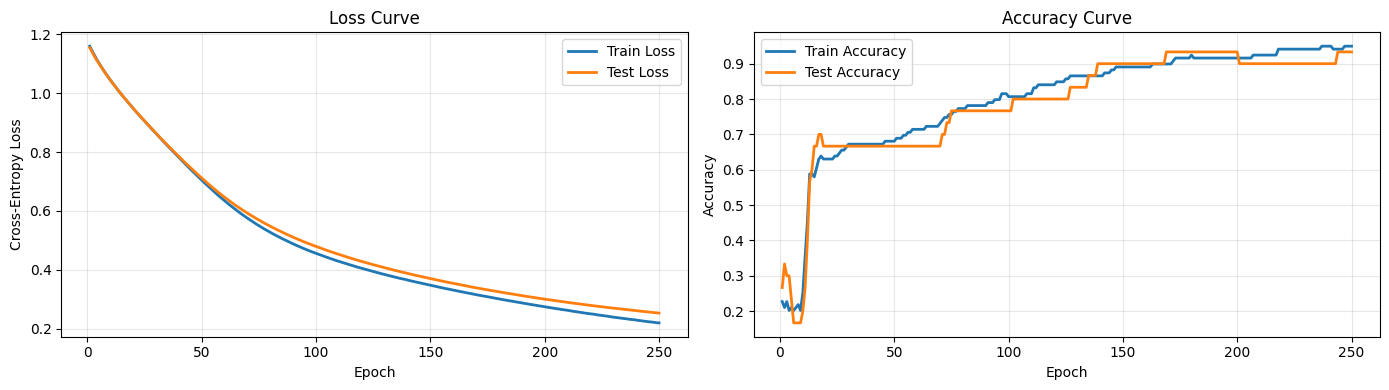

In [14]:
# 12) Graphs: loss and accuracy curves

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_df['epoch'], history_df['test_loss'], label='Test Loss', linewidth=2)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_df['epoch'], history_df['test_accuracy'], label='Test Accuracy', linewidth=2)
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# 13) Classification diagnostics

print('Classification report (test set):')
print(classification_report(y_test_int, y_test_pred, target_names=[str(c) for c in class_names]))

cm = confusion_matrix(y_test_int, y_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f'true_{c}' for c in class_names],
    columns=[f'pred_{c}' for c in class_names],
)

print('Confusion Matrix:')
display(cm_df)

Classification report (test set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix:


,pred_0,pred_1,pred_2
true_0,10,0,0
true_1,0,9,1
true_2,0,1,9
